# Step 5 — Explore momentum and future outperformance

This notebook asks whether AAPL's recent five-day direction is associated with outperforming SPY over the next five trading days. This is exploratory analysis across the full dataset—not an out-of-sample model evaluation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "aapl_momentum_target.csv"
data = pd.read_csv(DATA_PATH, parse_dates=["date"], index_col="date")
data.head()

,aapl_adjusted_close,spy_adjusted_close,aapl_momentum_5d,aapl_future_return_5d,spy_future_return_5d,outperformed
date,,,,,,
2023-01-10,128.548233,373.466339,0.045254,0.034269,0.002330,1
2023-01-11,131.262222,378.189850,0.056426,0.013334,-0.017395,1
2023-01-12,131.183533,379.566772,0.067109,0.033431,-0.002721,1
2023-01-13,132.510986,381.039276,0.039654,0.047121,0.005345,1
2023-01-17,133.671341,380.341309,0.044487,0.048477,0.006109,1


## Distribution of five-day momentum

The histogram shows how often different recent returns occurred. The vertical line marks zero momentum.

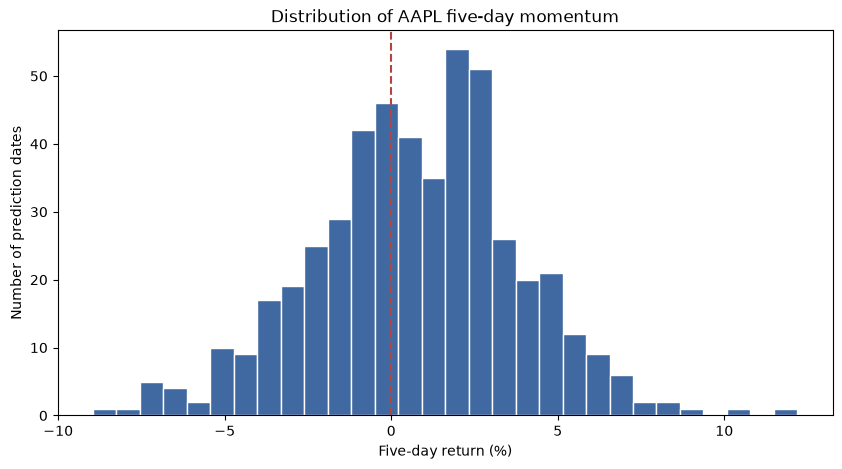

count    492.00
mean       0.76
std        3.12
min       -8.96
25%       -1.18
50%        0.77
75%        2.76
max       12.19
Name: aapl_momentum_5d, dtype: float64

In [2]:
momentum_pct = data["aapl_momentum_5d"] * 100
ax = momentum_pct.plot.hist(bins=30, figsize=(10, 5), color="#4169a1", edgecolor="white")
ax.axvline(0, color="#b2453f", linestyle="--", linewidth=1.5)
ax.set_title("Distribution of AAPL five-day momentum")
ax.set_xlabel("Five-day return (%)")
ax.set_ylabel("Number of prediction dates")
plt.show()

momentum_pct.describe().round(2)

## Positive versus negative momentum

For a first simple comparison, we label momentum as positive when the five-day return is at least zero and negative when it is below zero.

In [3]:
data["momentum_direction"] = data["aapl_momentum_5d"].ge(0).map({True: "Positive", False: "Negative"})

direction_comparison = (
    data.groupby("momentum_direction", sort=False)
    .agg(
        prediction_dates=("outperformed", "size"),
        later_outperformance_rate=("outperformed", "mean"),
        average_momentum=("aapl_momentum_5d", "mean"),
    )
)
direction_comparison[["later_outperformance_rate", "average_momentum"]] *= 100
direction_comparison.round(2)

,prediction_dates,later_outperformance_rate,average_momentum
momentum_direction,,,
Positive,302,53.64,2.69
Negative,190,54.21,-2.31


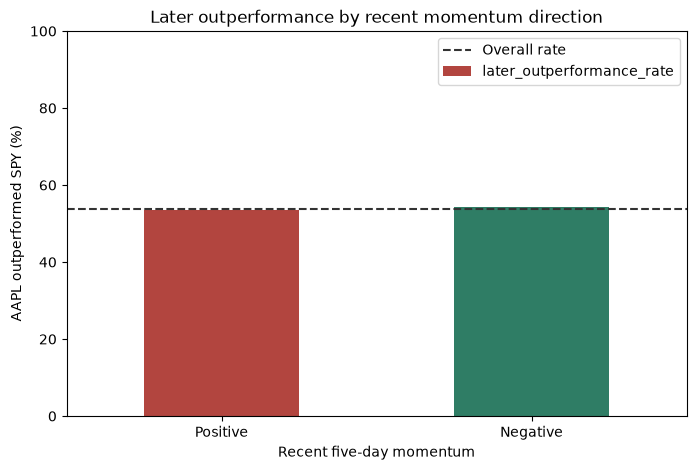

In [4]:
ax = direction_comparison["later_outperformance_rate"].plot.bar(
    figsize=(8, 5), color=["#b2453f", "#2f7d65"], rot=0
)
ax.axhline(data["outperformed"].mean() * 100, color="#333333", linestyle="--", label="Overall rate")
ax.set_ylim(0, 100)
ax.set_title("Later outperformance by recent momentum direction")
ax.set_xlabel("Recent five-day momentum")
ax.set_ylabel("AAPL outperformed SPY (%)")
ax.legend()
plt.show()

## Compare five momentum-strength groups

We rank all prediction dates by momentum and split them into five similarly sized groups. Group 1 contains the weakest recent performance; Group 5 contains the strongest. If momentum has a simple positive relationship with the target, outperformance rates should generally rise from Group 1 to Group 5.

In [5]:
labels = ["1 — Weakest", "2", "3", "4", "5 — Strongest"]
data["momentum_group"] = pd.qcut(data["aapl_momentum_5d"], q=5, labels=labels)

group_comparison = (
    data.groupby("momentum_group", observed=True)
    .agg(
        prediction_dates=("outperformed", "size"),
        minimum_momentum=("aapl_momentum_5d", "min"),
        maximum_momentum=("aapl_momentum_5d", "max"),
        later_outperformance_rate=("outperformed", "mean"),
    )
)
percent_columns = ["minimum_momentum", "maximum_momentum", "later_outperformance_rate"]
group_comparison[percent_columns] *= 100
group_comparison.round(2)

,prediction_dates,minimum_momentum,maximum_momentum,later_outperformance_rate
momentum_group,,,,
1 — Weakest,99,-8.96,-1.74,52.53
2,98,-1.73,0.06,55.10
3,98,0.06,1.71,55.10
4,98,1.71,3.21,55.10
5 — Strongest,99,3.22,12.19,51.52


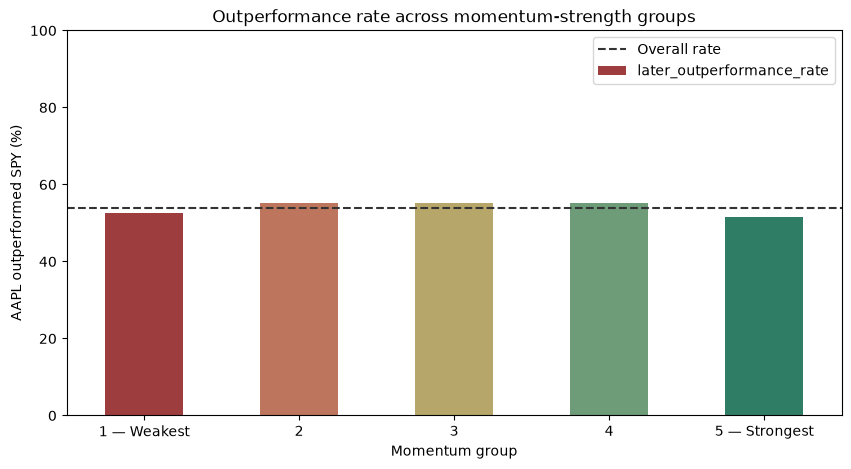

In [6]:
ax = group_comparison["later_outperformance_rate"].plot.bar(
    figsize=(10, 5), color=["#9d3d3d", "#bd765d", "#b7a66a", "#6e9b78", "#2f7d65"], rot=0
)
ax.axhline(data["outperformed"].mean() * 100, color="#333333", linestyle="--", label="Overall rate")
ax.set_ylim(0, 100)
ax.set_title("Outperformance rate across momentum-strength groups")
ax.set_xlabel("Momentum group")
ax.set_ylabel("AAPL outperformed SPY (%)")
ax.legend()
plt.show()

## Where momentum reversed

These examples help prevent us from telling an overly simple story. Strong positive momentum can be followed by underperformance, while strongly negative momentum can be followed by outperformance.

In [7]:
strongest_failures = (
    data.loc[data["outperformed"].eq(0)]
    .nlargest(5, "aapl_momentum_5d")
    [["aapl_momentum_5d", "aapl_future_return_5d", "spy_future_return_5d"]]
) * 100

weakest_reversals = (
    data.loc[data["outperformed"].eq(1)]
    .nsmallest(5, "aapl_momentum_5d")
    [["aapl_momentum_5d", "aapl_future_return_5d", "spy_future_return_5d"]]
) * 100

print("Strong positive momentum followed by underperformance (%)")
display(strongest_failures.round(2))
print("Strong negative momentum followed by outperformance (%)")
display(weakest_reversals.round(2))

Strong positive momentum followed by underperformance (%)


,aapl_momentum_5d,aapl_future_return_5d,spy_future_return_5d
date,,,
2024-06-17,12.19,-3.51,-0.09
2024-06-13,10.16,-3.15,0.70
2024-06-12,8.78,-1.59,1.04
2024-05-03,8.32,-0.04,1.87
2024-06-14,7.92,-2.05,0.32


Strong negative momentum followed by outperformance (%)


,aapl_momentum_5d,aapl_future_return_5d,spy_future_return_5d
date,,,
2023-08-07,-8.96,0.48,-0.58
2023-08-08,-8.08,-1.17,-1.31
2023-08-09,-7.47,-0.78,-1.37
2023-09-12,-7.06,1.57,-0.39
2023-08-10,-6.90,-2.10,-2.16


## Important limitation

These comparisons use every date in the dataset and therefore describe this particular period. They do not show how an unseen-period model performs. The next modeling step will use a chronological split so later observations remain unavailable during training.